# Workbench do Solver

Notebook de demonstracao orientado por narrativa. O objetivo aqui e responder, em ordem, qual problema esta sendo resolvido, o que torna o cenario dificil, como a rede deve ser lida, qual foi a solucao produzida e qual takeaway deve entrar na apresentacao.

In [13]:
from pathlib import Path
from IPython.display import Markdown, display

PROJECT_ROOT = next(parent for parent in [Path.cwd(), *Path.cwd().parents] if (parent / 'pyproject.toml').exists())
NOTEBOOK_DIR = PROJECT_ROOT / 'notebook'
import sys
if str(PROJECT_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'src'))
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from solver_workbench_support import (
    analyze_scenario,
    build_takeaway,
    compile_scenario,
    export_presentation_bundle,
    fleet_assignment_rows,
    load_scenario_artifacts,
    plot_base_graph,
    plot_kpi_dashboard,
    plot_solution_graph,
    route_sequences,
    run_scenario,
    summarize_fleet_usage,
    summarize_dataset,
    summarize_orchestration,
)

SCENARIO = 'operacao_sob_pressao'
MAX_ITERATIONS = 1000
SEED = 20260411
WITH_BASEMAP = True
EXPORT_DIR = PROJECT_ROOT / 'docs' / 'apresentacao' / 'assets' / 'generated' / 'notebook'
display(Markdown(f'**Configuracao ativa**: cenario=`{SCENARIO}`, max_iterations=`{MAX_ITERATIONS}`, seed=`{SEED}`'))

**Configuracao ativa**: cenario=`operacao_sob_pressao`, max_iterations=`1000`, seed=`20260411`

## 1. Qual problema estou resolvendo?

In [14]:
compile_scenario(SCENARIO)
ARTIFACTS = load_scenario_artifacts(SCENARIO)
DATASET_SUMMARY = summarize_dataset(ARTIFACTS)
SCENARIO_ANALYSIS = analyze_scenario(ARTIFACTS)
DATASET_SUMMARY | {'dominant_bottleneck': SCENARIO_ANALYSIS['dominant_bottleneck'], 'priority_ratio': SCENARIO_ANALYSIS['priority_ratio']}

{'cenario': 'operacao_sob_pressao',
 'cenario_legivel': 'Operação Sob Pressão',
 'dataset_dir': '/home/thiagobibianodasilva/Documentos/aredes-roteirizacao-numerario/data/fake_smoke',
 'data_operacao': '2026-03-21',
 'bases': 5,
 'pontos_catalogados': 30,
 'viaturas': 10,
 'ordens_do_dia': 20,
 'arcos_matriz': 625,
 'estrategia_matriz': 'synthetic_geodesic_v1',
 'fonte_matriz': 'operacao_sob_pressao_source',
 'dominant_bottleneck': 'dispersao_geografica',
 'priority_ratio': 0.4}

## 2. O que torna esse cenario dificil?

In [15]:
display(Markdown(
    f"**Leitura do gargalo**: `{SCENARIO_ANALYSIS['dominant_bottleneck']}`. "
    f"Janela media: `{SCENARIO_ANALYSIS['avg_window_hours']}` h, "
    f"pressao financeira: `{SCENARIO_ANALYSIS['cash_pressure_ratio']}`, "
    f"pressao volumetrica: `{SCENARIO_ANALYSIS['volume_pressure_ratio']}`."
))
SCENARIO_ANALYSIS

**Leitura do gargalo**: `dispersao_geografica`. Janela media: `3.77` h, pressao financeira: `0.479`, pressao volumetrica: `0.039`.

{'cenario': 'operacao_sob_pressao',
 'total_ordens': 20,
 'total_viaturas': 10,
 'total_especiais': 8,
 'priority_ratio': 0.4,
 'avg_window_hours': 3.77,
 'avg_value': 1278500.0,
 'avg_volume': 36.6,
 'cash_pressure_ratio': 0.479,
 'volume_pressure_ratio': 0.039,
 'geo_span_longitude': 0.4047,
 'geo_span_latitude': 0.3833,
 'dominant_bottleneck': 'dispersao_geografica'}

## 3. Como a rede-base deve ser lida?

(<Figure size 1200x800 with 1 Axes>,
 <Axes: title={'center': 'Rede-base do cenário Operação Sob Pressão com basemap'}, xlabel='Longitude', ylabel='Latitude'>)

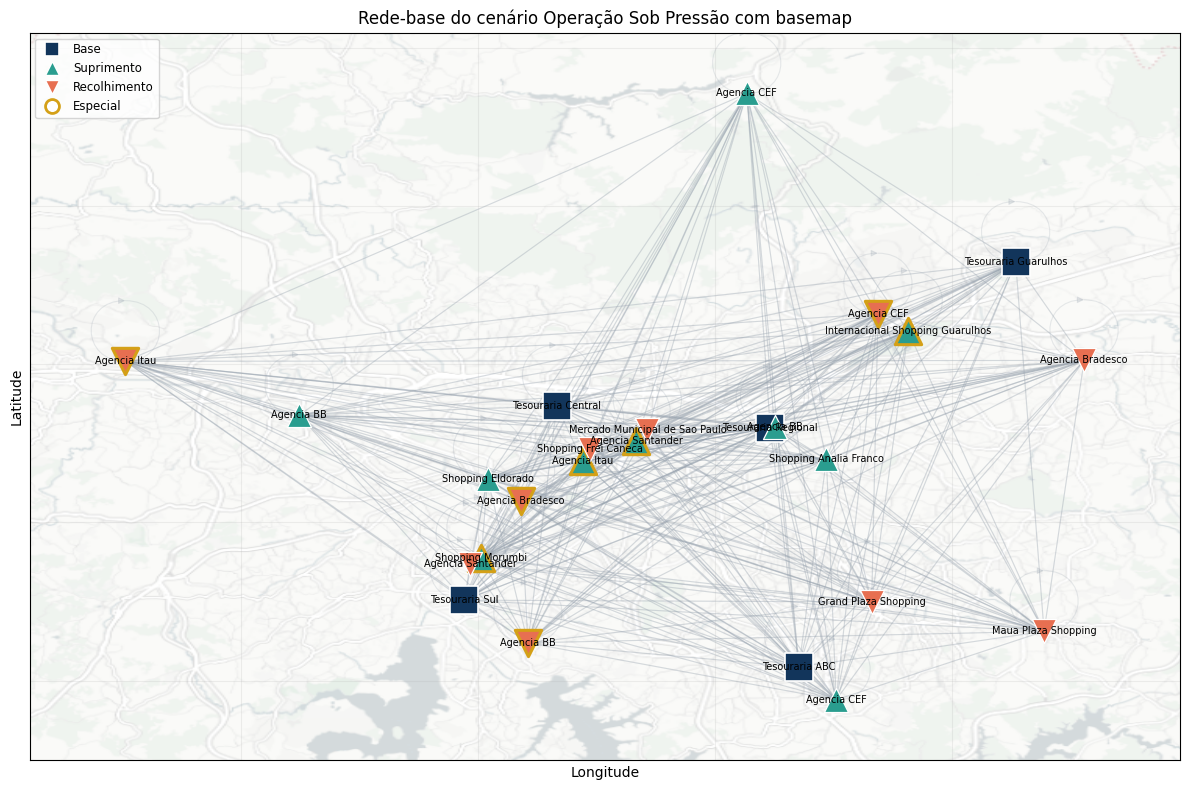

In [16]:
plot_base_graph(ARTIFACTS, with_basemap=WITH_BASEMAP)

## 4. Quais parametros de execucao governam a leitura da solucao?

In [17]:
{
    'scenario': SCENARIO,
    'max_iterations': MAX_ITERATIONS,
    'seed': SEED,
    'materialize_snapshot': True,
    'service_policy': 'maximize_attendance_v1',
}

{'scenario': 'operacao_sob_pressao',
 'max_iterations': 1000,
 'seed': 20260411,
 'materialize_snapshot': True,
 'service_policy': 'maximize_attendance_v1'}

## 5. O que o solver construiu?

In [18]:
ORCHESTRATION = run_scenario(
    SCENARIO,
    max_iterations=MAX_ITERATIONS,
    seed=SEED,
    materialize_snapshot=True,
)
SUMMARY = summarize_orchestration(ORCHESTRATION)
FLEET_SUMMARY = summarize_fleet_usage(ORCHESTRATION)
SUMMARY

{'id_execucao': 'exec-smoke-2026-03-21',
 'status_final': 'concluida_com_ressalvas',
 'hash_cenario': '93d9503fc711f17dc0a51d70443e2dba96bdb6d9d5caf71ca6032ab8152fe239',
 'reused_cached_result': False,
 'recovered_previous_context': False,
 'attempt_number': 1,
 'total_rotas': 12,
 'rotas_suprimento': 7,
 'rotas_recolhimento': 5,
 'ordens_planejadas': 19,
 'ordens_nao_atendidas': 1,
 'taxa_atendimento': '0.9500',
 'utilizacao_frota': '0.9000',
 'viaturas_acionadas_unicas': 9,
 'alocacoes_viatura_rota': 12,
 'viaturas_reutilizadas': 3,
 'viaturas_reutilizadas_entre_classes': 3,
 'ids_viaturas_reutilizadas_entre_classes': ['V-CENTRO-01',
  'V-LESTE-01',
  'V-SUL-01'],
 'custo_total_estimado': '11147.06',
 'resultado_json': '/home/thiagobibianodasilva/Documentos/aredes-roteirizacao-numerario/data/fake_smoke/outputs/executions/93d9503fc711f17dc0a51d70443e2dba96bdb6d9d5caf71ca6032ab8152fe239/resultado-planejamento.json',
 'observacao_frota': 'Suprimento e recolhimento são resolvidos em inst

(<Figure size 1200x800 with 1 Axes>,
 <Axes: title={'left': 'Rede escolhida pelo solver com basemap\n19 ordem(ns) planejada(s) | 1 não atendida(s)'}, xlabel='Longitude', ylabel='Latitude'>)

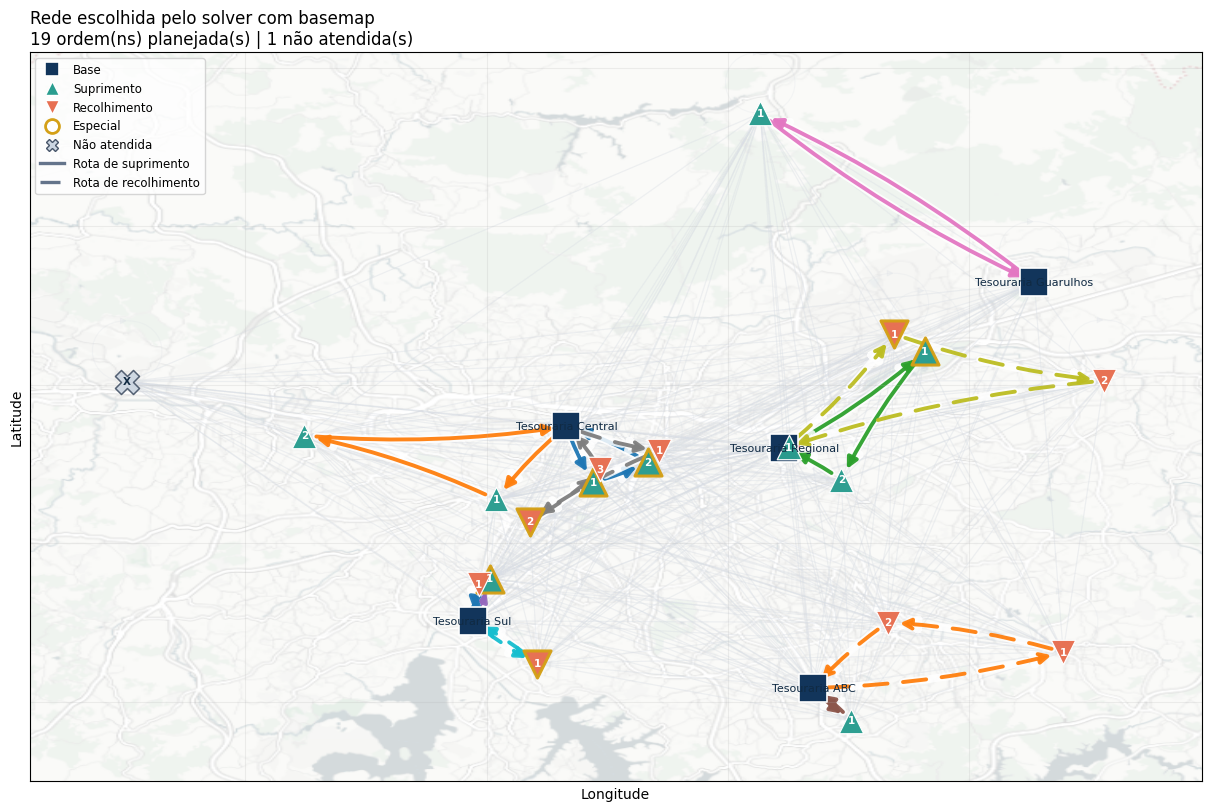

In [19]:
plot_solution_graph(ORCHESTRATION, ARTIFACTS, with_basemap=WITH_BASEMAP, show_order_details=False, show_route_summary=False)

## 6. Como ler rotas e viaturas neste resultado?

In [20]:
FLEET_SUMMARY

{'alocacoes_viatura_rota': 12,
 'viaturas_unicas': 9,
 'viaturas_reutilizadas': 3,
 'viaturas_reutilizadas_entre_classes': 3,
 'ids_viaturas_reutilizadas': ['V-CENTRO-01', 'V-LESTE-01', 'V-SUL-01'],
 'ids_viaturas_reutilizadas_entre_classes': ['V-CENTRO-01',
  'V-LESTE-01',
  'V-SUL-01'],
 'rotas_por_viatura_unica': 1.33,
 'leitura_correta': 'Suprimento e recolhimento são resolvidos em instâncias separadas. Por isso, o mesmo ID de viatura pode aparecer em mais de uma rota e `viaturas_acionadas_unicas` pode ser menor que `total_rotas`.'}

In [21]:
fleet_assignment_rows(ORCHESTRATION)

[{'Viatura': 'V-CENTRO-01',
  'Classes': 'recolhimento + suprimento',
  'Total de rotas': 2,
  'Rotas': 'rota-exec-smoke-2026-03-21-suprimento-001, rota-exec-smoke-2026-03-21-recolhimento-001',
  'Reuso entre classes': 'sim'},
 {'Viatura': 'V-LESTE-01',
  'Classes': 'recolhimento + suprimento',
  'Total de rotas': 2,
  'Rotas': 'rota-exec-smoke-2026-03-21-suprimento-003, rota-exec-smoke-2026-03-21-recolhimento-002',
  'Reuso entre classes': 'sim'},
 {'Viatura': 'V-SUL-01',
  'Classes': 'recolhimento + suprimento',
  'Total de rotas': 2,
  'Rotas': 'rota-exec-smoke-2026-03-21-suprimento-005, rota-exec-smoke-2026-03-21-recolhimento-003',
  'Reuso entre classes': 'sim'}]

## 7. Qual foi o saldo operacional em KPI e sequência?

(<Figure size 1200x400 with 4 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object))

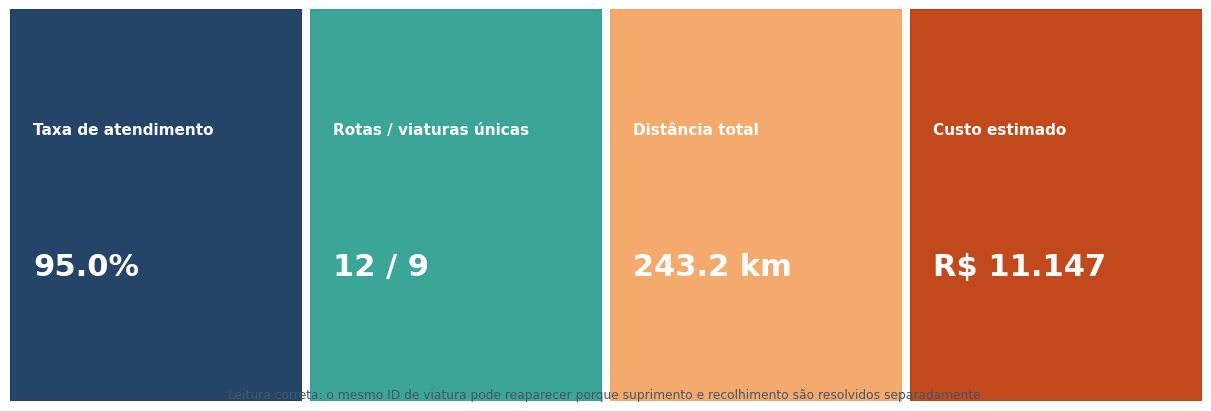

In [22]:
plot_kpi_dashboard(ORCHESTRATION)

In [23]:
route_sequences(ORCHESTRATION)

[{'id_rota': 'rota-exec-smoke-2026-03-21-suprimento-001',
  'id_viatura': 'V-CENTRO-01',
  'classe_operacional': 'suprimento',
  'quantidade_paradas': 2,
  'inicio_previsto': '2026-03-21T10:50:02+00:00',
  'fim_previsto': '2026-03-21T16:35:24+00:00',
  'sequencia': 'BASE-SP-CENTRO -> P-CENTRO-01 -> P-CENTRO-04 -> BASE-SP-CENTRO',
  'ordens': ['ORD-001-Paul-Sup', 'ORD-016-RDireita-Sup']},
 {'id_rota': 'rota-exec-smoke-2026-03-21-suprimento-002',
  'id_viatura': 'V-CENTRO-02',
  'classe_operacional': 'suprimento',
  'quantidade_paradas': 2,
  'inicio_previsto': '2026-03-21T07:52:45+00:00',
  'fim_previsto': '2026-03-21T10:17:11+00:00',
  'sequencia': 'BASE-SP-CENTRO -> P-OESTE-02 -> P-OESTE-06 -> BASE-SP-CENTRO',
  'ordens': ['ORD-004-Eldo-Sup', 'ORD-018-Osasco-Sup']},
 {'id_rota': 'rota-exec-smoke-2026-03-21-suprimento-003',
  'id_viatura': 'V-LESTE-01',
  'classe_operacional': 'suprimento',
  'quantidade_paradas': 2,
  'inicio_previsto': '2026-03-21T08:37:53+00:00',
  'fim_previsto': '

## 8. Qual takeaway entra na apresentação?

In [24]:
display(Markdown(build_takeaway(ORCHESTRATION, ARTIFACTS)))
export_presentation_bundle(ORCHESTRATION, ARTIFACTS, output_dir=EXPORT_DIR, with_basemap=WITH_BASEMAP)

No cenário Operação Sob Pressão, o gargalo dominante é dispersão geográfica. O solver encerrou com status concluída com ressalvas, planejou 19 ordem(ns), deixou 1 não atendida(s) e acionou 12 rota(s). A leitura principal para apresentação é comparar cobertura e custo com esse gargalo em mente, sem tratar a sequência exata de visitas como critério científico principal.

{'base_map': '/home/thiagobibianodasilva/Documentos/aredes-roteirizacao-numerario/docs/apresentacao/assets/generated/notebook/operacao_sob_pressao_rede_base.png',
 'solution_map': '/home/thiagobibianodasilva/Documentos/aredes-roteirizacao-numerario/docs/apresentacao/assets/generated/notebook/operacao_sob_pressao_solucao.png',
 'kpi_panel': '/home/thiagobibianodasilva/Documentos/aredes-roteirizacao-numerario/docs/apresentacao/assets/generated/notebook/operacao_sob_pressao_kpis.png',
 'takeaway': '/home/thiagobibianodasilva/Documentos/aredes-roteirizacao-numerario/docs/apresentacao/assets/generated/notebook/operacao_sob_pressao_takeaway.txt'}